## Demand Forecasting & Model Explainability

The objective of this notebook is to forecast product demand and revenue trends and explain the key business drivers behind those forecasts.
This analysis supports inventory planning, pricing decisions, and promotion strategy by identifying what actually drives demand in a retail environment.

The notebook progresses from:

- Baseline time-series forecasting

- Category-level demand analysis

- Machine learning–based demand prediction

- Model explainability using feature importance

The final output bridges predictive modeling with actionable business insights, setting the foundation for inventory optimization and scenario simulation.

Retail decisions are not made on raw transactions.
They require:

- Reliable demand forecasts

- Understanding why demand changes

- Translating predictions into inventory and pricing actions

This notebook ensures forecasts are explainable, realistic, and operationally useful.

### Importing Libraries and Loading dataset

In [ ]:
import pandas as pd #importing pandas for data manipulation
import numpy as np #importing numpy for mathematical calculations
import matplotlib.pyplot as plt #importing matplotlib for charts
import seaborn as sns #importing seaborn for advanced charts
from sklearn.preprocessing import OneHotEncoder #for one hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error #for checking the metrics

In [ ]:
df=pd.read_csv("cleaned_BrightMart_retail_dataset.csv")
df['Transaction Date']= pd.to_datetime(df['Transaction Date'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Category          12575 non-null  object        
 1   Item              12575 non-null  object        
 2   Price Per Unit    12575 non-null  float64       
 3   Quantity          12575 non-null  float64       
 4   Payment Method    12575 non-null  object        
 5   Location          12575 non-null  object        
 6   Transaction Date  12575 non-null  datetime64[ns]
 7   Discount Applied  12575 non-null  bool          
 8   Season            12575 non-null  object        
 9   Month             12575 non-null  object        
 10  Weekday           12575 non-null  object        
 11  Stock On Hand     12575 non-null  int64         
 12  Promotion         12575 non-null  int64         
 13  Revenue           12575 non-null  float64       
dtypes: bool(1), datetime64

,Category,Item,Price Per Unit,Quantity,Payment Method,Location,Transaction Date,Discount Applied,Season,Month,Weekday,Stock On Hand,Promotion,Revenue
0,Patisserie,Item_10_Pat,18.5,10.0,Digital Wallet,Online,2024-04-08,True,Spring,April,Monday,152,10,166.50
1,Milk Products,Item_17_Milk,29.0,9.0,Digital Wallet,Online,2023-07-23,True,Summer,July,Sunday,142,10,234.90
2,Butchers,Item_12_But,21.5,2.0,Credit Card,Online,2022-10-05,True,Fall,October,Wednesday,64,10,38.70
3,Beverages,Item_16_Bev,27.5,9.0,Credit Card,Online,2022-05-07,True,Spring,May,Saturday,156,10,222.75
4,Food,Item_6_Food,12.5,7.0,Digital Wallet,Online,2022-10-02,False,Fall,October,Sunday,121,0,87.50


### Revenue Forecasting (Monthly Level)
Objective:
The goal of this step is to forecast monthly revenue trends to support business decisions such as inventory planning, promotion timing, and revenue target setting. We begin at the monthly level to capture seasonality and long-term trends before moving to granular forecasts.

In [ ]:
#extracting year and month from the dataset and making a seaparate column.
df['Year Month']= df['Transaction Date'].dt.strftime('%Y-%m')
#Grouping data by Year_Month and calculating total revenue
monthly_revenue= df.groupby('Year Month')['Revenue'].sum().reset_index()
# Converting 'Year Month' back to datetime format for plotting
monthly_revenue['Year Month'] = pd.to_datetime(monthly_revenue['Year Month'])
monthly_revenue.head()

,Year Month,Revenue
0,2022-01-01,53769.496776
1,2022-02-01,43792.321154
2,2022-03-01,41519.631794
3,2022-04-01,40418.405276
4,2022-05-01,40476.674815


#### We aggregate revenue at a monthly level to reduce transaction-level noise and clearly observe seasonality, trends, and demand cycles.

### Monthly Revenue Line Chart

Monthly Revenue Forecasting (Baseline)
Purpose

We begin at a monthly aggregation level to:

- Reduce transaction-level noise

- Identify seasonality and long-term trends

- Establish a baseline forecast before applying ML models

- Monthly forecasting is especially useful for high-level planning, budgeting, and strategic inventory decisions.

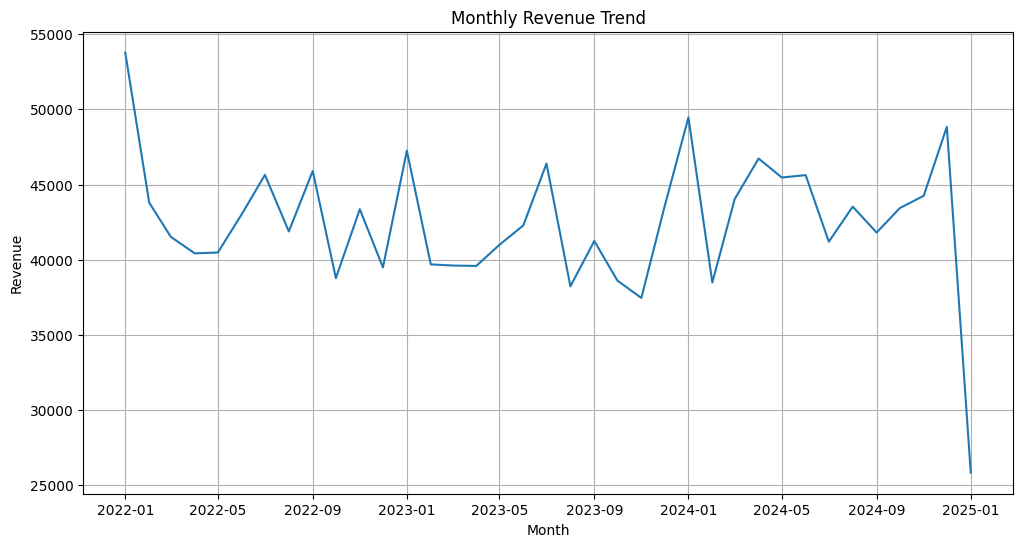

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['Year Month'], monthly_revenue['Revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

#### The monthly revenue trend shows clear fluctuations over time, indicating seasonality and demand cycles. This confirms that forecasting can provide actionable insights for future planning.

In [ ]:
# Creating rolling mean forecast
monthly_revenue['rolling_mean_3_Month_Avg']= (monthly_revenue['Revenue'].rolling(window=3).mean())
monthly_revenue.head()

,Year Month,Revenue,rolling_mean_3_Month_Avg
0,2022-01-01,53769.496776,NaN
1,2022-02-01,43792.321154,NaN
2,2022-03-01,41519.631794,46360.483241
3,2022-04-01,40418.405276,41910.119408
4,2022-05-01,40476.674815,40804.903962


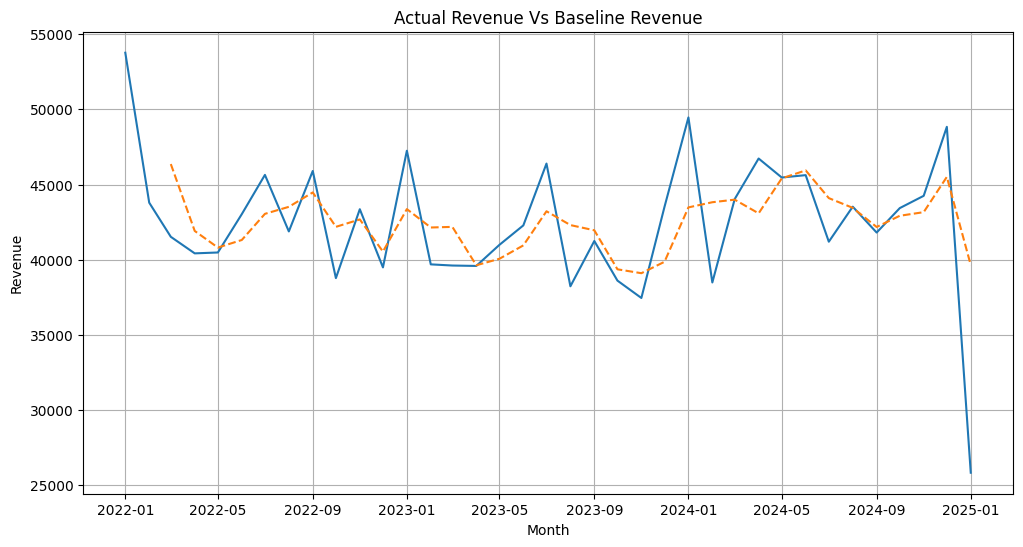

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['Year Month'], monthly_revenue['Revenue'], label='Actual_Revenue')
plt.plot(monthly_revenue['Year Month'],monthly_revenue['rolling_mean_3_Month_Avg'],linestyle='--',label='Forcasted Revenue')
plt.title("Actual Revenue Vs Baseline Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Key Insight

- Revenue shows clear fluctuations over time, confirming seasonality and demand cycles.

- Forecasting is therefore meaningful and actionable.

#### The rolling average forecast smooths short-term volatility and captures overall revenue direction. However, it reacts slowly to sudden changes such as promotions or seasonal spikes, indicating the need for more advanced forecasting methods.

#### Baseline Forecast: 3-Month Rolling Average
Why a Rolling Mean?

- Simple and interpretable

- Serves as a benchmark for advanced models

- Helps evaluate whether ML models add real value

In [ ]:
#evaluating the rolling_mean_3_Month_Avg
evaluation= monthly_revenue.dropna()#dropping the missing values
#evaluating by using mean_absolute_error and mean_squared_error
mae= mean_absolute_error(evaluation['Revenue'], evaluation['rolling_mean_3_Month_Avg'])
rsme= np.sqrt(mean_squared_error(evaluation['Revenue'], evaluation['rolling_mean_3_Month_Avg']))
mae, rsme

(2339.9467716185045, np.float64(3452.932928251024))

#### On average, our rolling mean forecast is off by about 2,340 units of revenue per month.
#### When the model makes mistakes, some months experience large deviations from actual revenue.
#### The fact that RMSE > MAE tells us:

- There are some months with big forecasting errors

- Likely due to promotions, seasonality, or demand spikes

#### Model Evaluation – Rolling Mean Forecast

- We evaluated the 3-month rolling mean forecast using MAE and RMSE to measure how closely predicted revenue matches actual revenue.

- MAE (2,340) indicates the average monthly deviation between actual and predicted revenue.

- RMSE (3,453) is higher than MAE, suggesting the presence of months with larger forecasting errors.

- These results are expected, as the rolling mean model does not account for promotions, seasonality, or pricing changes. The rolling mean serves as a baseline model, providing a benchmark against which more advanced forecasting models can be compared.

Evaluation Results

MAE = 2,340 → Average monthly deviation

RMSE = 3,453 → Some months have large errors

Interpretation

Rolling averages smooth trends but:

- React slowly to promotions

- Miss sudden demand spikes

This confirms the need for models that incorporate external drivers.

### Category-Level Demand Forecasting
Retail inventory decisions are rarely made at total revenue level. Businesses plan procurement, shelf space, and promotions at the category level (e.g., Beverages, Food, Furniture). Forecasting demand by category enables targeted inventory optimization and promotion planning.

- Demand = Quantity sold (not revenue)

- Inventory is driven by units, not money

- Monthly aggregation captures seasonality

Why Category-Level Forecasting?

Inventory decisions are made in units, not revenue, and at the category level, not total sales.

Examples:

- Shelf space allocation

- Category-wise procurement

- Promotion planning

In [ ]:
# Aggregating quantity sold by Category and Month
category_monthly_revenue=(df.groupby(['Year Month', 'Category'])['Quantity'].sum().reset_index())
category_monthly_revenue.head()

,Year Month,Category,Quantity
0,2022-01,Beverages,246.0
1,2022-01,Butchers,365.0
2,2022-01,Computers And Electric Accessories,302.0
3,2022-01,Electric Household Essentials,230.0
4,2022-01,Food,249.0


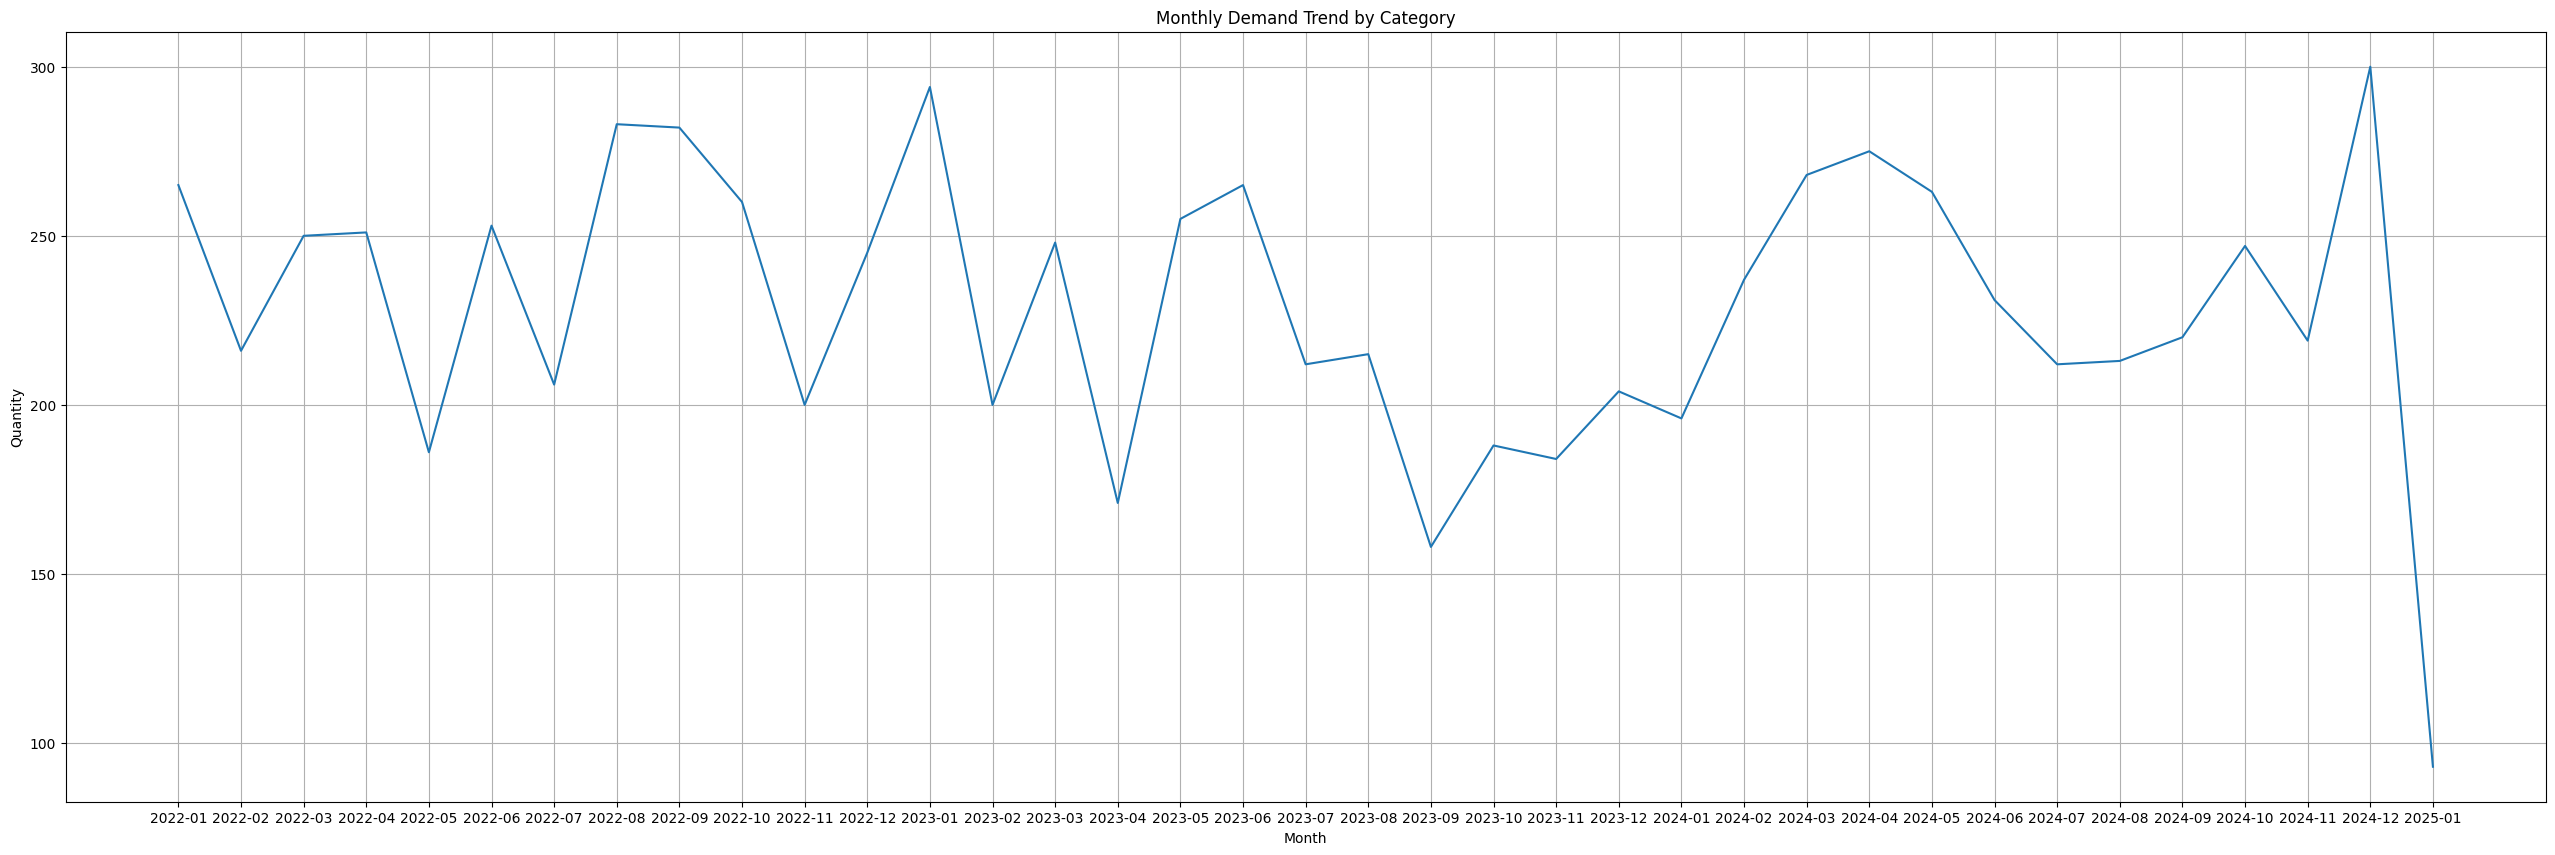

In [ ]:
plt.figure(figsize=(32,10))
categories= category_monthly_revenue['Category'].unique()
for cat in categories:
  category_data=category_monthly_revenue[category_monthly_revenue['Category']==cat]
plt.plot(category_data['Year Month'], category_data['Quantity'])
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.title('Monthly Demand Trend by Category')
plt.grid(True)
plt.show()

#### Rolling Forecast by Category

In [ ]:
category_monthly_revenue['Rolling_3_Month_Forecast']=(category_monthly_revenue.groupby('Category')['Quantity'].rolling(window=3).mean().reset_index(level=0, drop=True))
category_monthly_revenue.tail()

,Year Month,Category,Quantity,Rolling_3_Month_Forecast
291,2025-01,Electric Household Essentials,128.0,210.666667
292,2025-01,Food,186.0,242.000000
293,2025-01,Furniture,134.0,209.000000
294,2025-01,Milk Products,140.0,246.666667
295,2025-01,Patisserie,93.0,204.000000


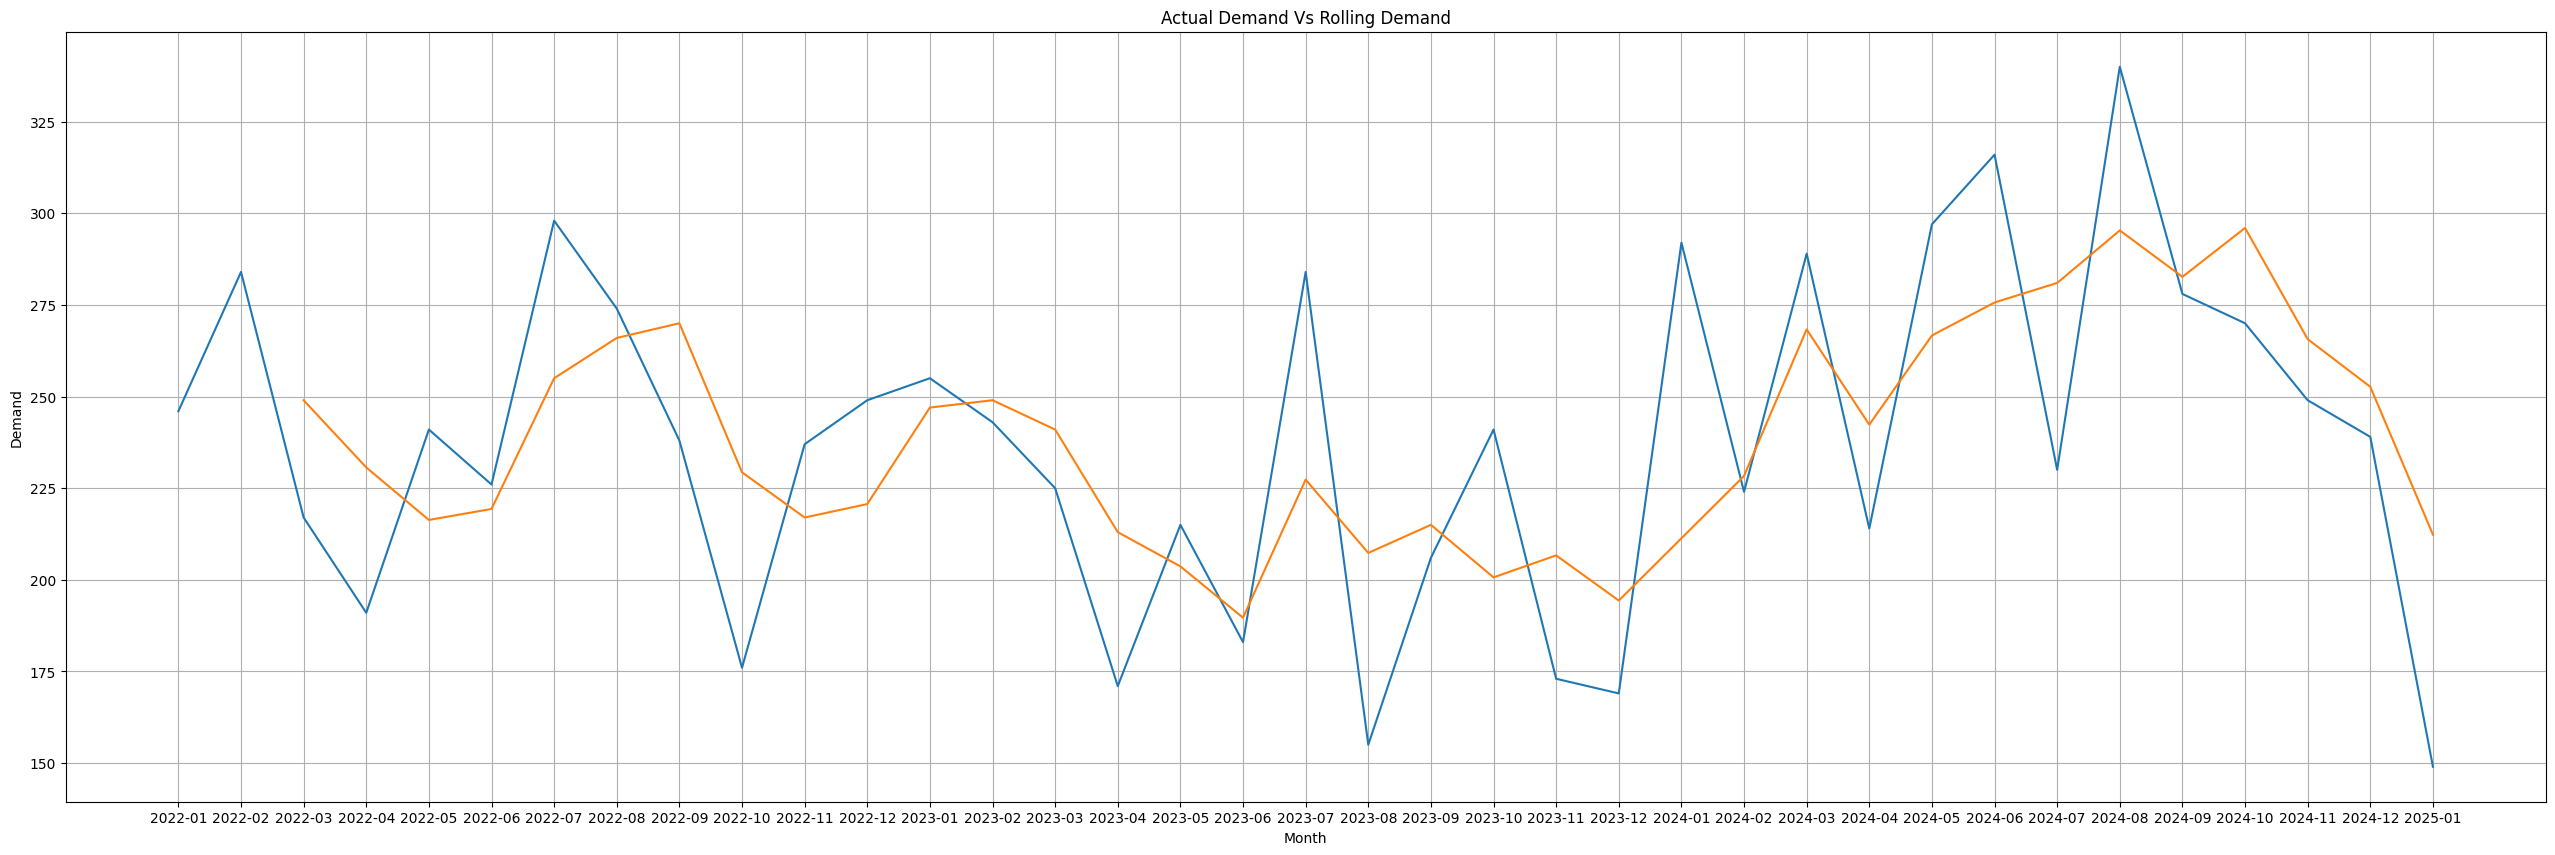

In [ ]:
demand_category = category_monthly_revenue['Category'].unique()[0]
data = category_monthly_revenue[category_monthly_revenue['Category'] == demand_category]
plt.figure(figsize=(32,10))
plt.plot(data['Year Month'], data['Quantity'], label="Actual Demand")
plt.plot(data['Year Month'], data['Rolling_3_Month_Forecast'], label="Forcasted Demand")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.title("Actual Demand Vs Rolling Demand")
plt.grid(True)
plt.show()

#### The baseline forecast captures general demand direction but reacts slowly to sudden changes such as promotions or seasonal spikes. This highlights the need for advanced forecasting models that incorporate external drivers.

In [ ]:
forecast_accuracy = []

for category in category_monthly_revenue['Category'].unique():
    temp = category_monthly_revenue[(category_monthly_revenue['Category'] == category) &(category_monthly_revenue['Rolling_3_Month_Forecast'].notna())]
    mae = mean_absolute_error(temp['Quantity'], temp['Rolling_3_Month_Forecast'])
    forecast_accuracy.append({'Category': category,'MAE': round(mae, 2)})

forecast_accuracy_df = pd.DataFrame(forecast_accuracy)
forecast_accuracy_df

,Category,MAE
0,Beverages,29.13
1,Butchers,26.26
2,Computers And Electric Accessories,30.63
3,Electric Household Essentials,25.79
4,Food,24.92
5,Furniture,24.54
6,Milk Products,31.53
7,Patisserie,24.35


#### Forecast accuracy varies across categories, reinforcing the importance of category-specific models rather than a one-size-fits-all approach.

#### Inventory Insight
- Categories with higher forecast error require higher safety stock, while stable categories can operate with leaner inventory levels.
- These insights will be used later for inventory optimization and stock-out risk simulation.

Key Insight

- Demand patterns vary significantly across categories.

- Forecast accuracy differs by category, confirming:

- One-size-fits-all forecasting does not work in retail.

Inventory Implication

- Categories with higher forecast error require higher safety stock.

- Stable categories can operate with leaner inventory levels.

### Advanced Forecasting with ML (XGBoost / Random Forest)

##### Traditional forecasts (moving averages, ARIMA) rely only on past demand.
- In real retail environments, demand is influenced by price, promotions, seasonality, weekday effects, and stock availability.
- Machine Learning models allow us to incorporate these external drivers and generate more accurate, actionable forecasts.
- Target = Quantity (Units Sold)
 Inventory decisions depend on units, not revenue.

Traditional forecasting methods rely only on past demand.

However, real retail demand is influenced by:

- Price

- Promotions

- Seasonality

- Weekday effects

- Stock availability

ML Advantage

Machine learning models allow us to:

- Combine historical demand with business drivers

- Capture non-linear relationships

- Generate more realistic and actionable forecasts

Target Variable

- Quantity Sold
- Inventory decisions depend on units, not revenue.

Features Used (Known at Forecast Time)

- Price Per Unit

- Promotion Intensity

- Stock On Hand

- Season

- Month

- Weekday

- Category

This avoids data leakage and mirrors real-world forecasting conditions.

In [ ]:
target = df['Quantity']

#### Feature Selection
Features Used: We only use features that would be known at forecast time.

- Price Per Unit

- Promotion (%)

- Stock On Hand

- Season

- Month

- Weekday

- Category

In [ ]:
features =['Price Per Unit','Promotion','Stock On Hand','Season','Month','Weekday','Category']
X=df[features]
Y=target

#### Encoding the data

In [ ]:
num_cols=['Price Per Unit','Stock On Hand','Promotion']
cat_cols=['Season', 'Month', 'Weekday', 'Category']
preprocessor= ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
                                              ('num', 'passthrough', num_cols)])

#### Train-Test Split

In [ ]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.20, shuffle= False)

#### We do not shuffle because future data must not leak into past data.

### Train ML Model
We start with Random Forest because:

- Handles non-linearity

- Robust to outliers

In [ ]:
model= Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=175, max_depth=12, random_state=42))])
model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Season', 'Month', 'Weekday',
                                                   'Category']),
                                                 ('num', 'passthrough',
                                                  ['Price Per Unit',
                                                   'Stock On Hand',
                                                   'Promotion'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=12, n_estimators=175,
                                       random_state=42))])

### Model Evaluation
Metrics Used

- MAE → Business-friendly

- RMSE → Penalizes large errors

- MAPE → Relative accuracy

In [ ]:
Y_predict= model.predict(X_test)
mae= mean_absolute_error(Y_test, Y_predict)
rmse= np.sqrt(mean_squared_error(Y_test, Y_predict))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2.39
RMSE: 2.80


#### On average, demand prediction is wrong by 2.4 units per order.
If RMSE > MAE:
- There are dangerous errors hiding.

### Actual vs Predicted Visualization

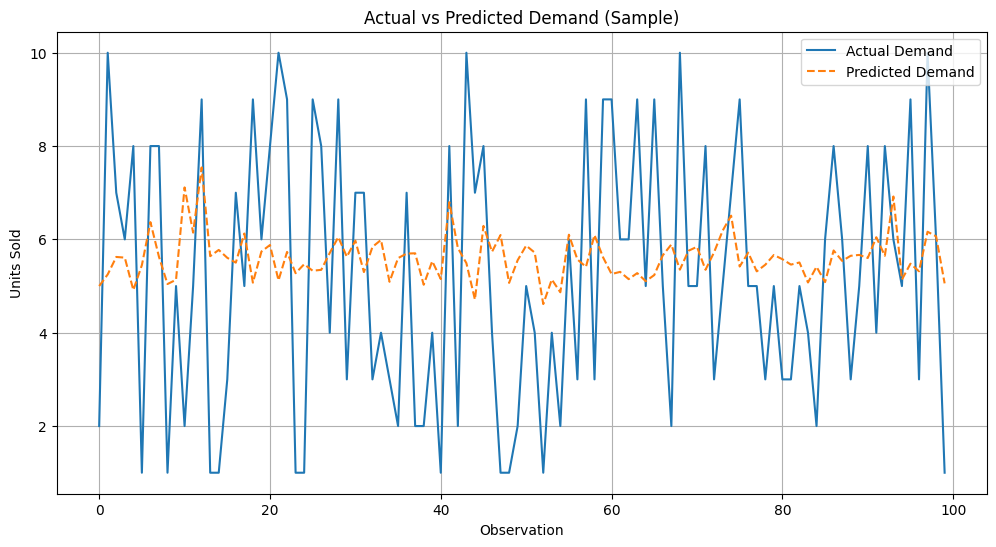

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(Y_test.values[:100], label="Actual Demand")
plt.plot(Y_predict[:100], label="Predicted Demand", linestyle='--')
plt.title('Actual vs Predicted Demand (Sample)')
plt.xlabel('Observation')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()

### Training Gradient Boosting Regressor Model

In [ ]:
gb_model= Pipeline(steps=[('preprocessor', preprocessor),('regressor', GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4,random_state=4 ))])
gb_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Season', 'Month', 'Weekday',
                                                   'Category']),
                                                 ('num', 'passthrough',
                                                  ['Price Per Unit',
                                                   'Stock On Hand',
                                                   'Promotion'])])),
                ('regressor',
                 GradientBoostingRegressor(max_depth=4, n_estimators=150,
                                           random_state=4))])

In [ ]:
Y_predict1 = gb_model.predict(X_test)
mae= mean_absolute_error(Y_test, Y_predict1)
rsme=np.sqrt(mean_squared_error(Y_test, Y_predict1))
print(f'MAE:{mae:.2f}')
print(f'RSME:{rsme:.2f}')

MAE:2.39
RSME:2.80


#### We observed:

- Random Forest → MAE = 2.39, RMSE = 2.80

- Gradient Boosting → MAE = 2.39, RMSE = 2.80

There is no meaningful performance difference.

##### We evaluated multiple models including Random Forest and Gradient Boosting. Since both models showed comparable performance, Random Forest was selected due to its interpretability, robustness, and suitability for explainable AI analysis.

#### Model Selection & Evaluation
Models Evaluated

- Random Forest Regressor

- Gradient Boosting Regressor

#### Evaluation Metrics

MAE → Business-friendly (average error in units)

RMSE → Penalizes large errors

#### Results

Both models achieved similar performance:

MAE = 2.39 units

RMSE =  2.80 units

Final Model Choice

Random Forest was selected due to:

- Comparable accuracy

- Better robustness

- Easier explainability

#### Model Explainability
Objective:
- Understand which factors most strongly influence demand predictions so business teams can make better pricing, promotion, and inventory decisions.

- Instead of advanced explainability tools (e.g., SHAP), we use feature importance from tree-based models, which is widely accepted in industry and easy to interpret.

##### Tree-based models such as Random Forest automatically calculate how important each feature is for making predictions.
##### Feature importance answers the question:
“Which variables does the model rely on the most when predicting demand?”
Instead of complex explainability tools, we use feature importance from tree-based models, which is:

- Widely accepted in industry

- Easy to communicate to business stakeholders

In [ ]:
model.named_steps['regressor'].feature_importances_
# Get trained Random Forest model
rf_model = model.named_steps['regressor']

# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance values
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
32,num__Stock On Hand,0.310737
31,num__Price Per Unit,0.180211
33,num__Promotion,0.048771
26,cat__Category_Electric Household Essentials,0.021181
28,cat__Category_Furniture,0.020674
24,cat__Category_Butchers,0.020241
23,cat__Category_Beverages,0.019580
30,cat__Category_Patisserie,0.019206
21,cat__Weekday_Tuesday,0.019099
29,cat__Category_Milk Products,0.018936


In [ ]:
feature_importance_df.to_csv("feature_importance.csv", index=False)

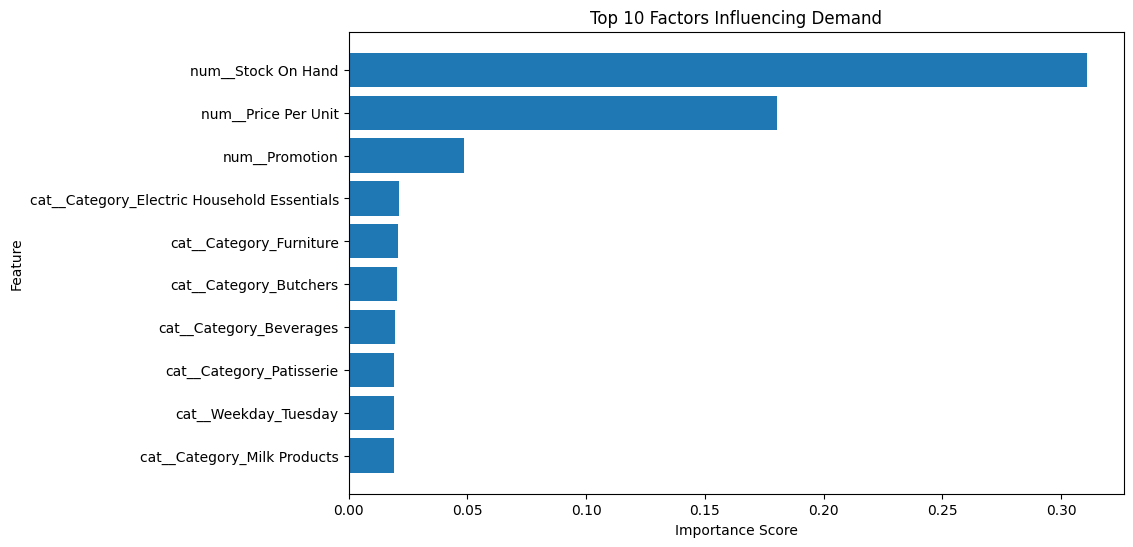

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['Feature'][:10][::-1],
    feature_importance_df['Importance'][:10][::-1]
)
plt.title("Top 10 Factors Influencing Demand")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

####Stock On Hand — Most Important Factor

- The model shows that inventory availability dominates demand prediction

- If stock is low, demand cannot be fulfilled even if interest exists
- Demand forecasting must be tightly integrated with inventory planning.

####Price Per Unit — Second Strongest Driver

- Customers are highly price-sensitive

- Small price changes meaningfully impact units sold

- Pricing strategy directly affects demand volume.

####Promotion — Positive but Secondary Impact

- Promotions boost demand, but only when stock is sufficient

- Promotions alone do not guarantee high sales

- Promotions should be paired with adequate inventory levels.

#### Category Effects — Structural Demand Differences

- Categories like:

      Electric Household Essentials

      Furniture

      Beverages

      Butchers

- Show distinct demand behavior
- Each category requires a customized pricing and inventory strategy.

#### Weekday Effects — Operational Pattern

- Tuesday appears as a statistically relevant demand day

- Suggests weekday-driven purchasing habits
- Staffing, replenishment, and promotions can be optimized by weekday patterns.

####Business Recommendations
####Inventory Optimization

- Maintain minimum stock thresholds for high-demand categories

- Prevent lost sales due to stockouts

####Pricing Strategy

- Use dynamic pricing for price-sensitive categories

- Avoid uniform price changes across all products

#### Promotion Planning

- Run promotions only when inventory is sufficient

- Avoid demand spikes that cause stockouts

#### Category-Specific Strategy

- Apply differentiated policies for:

      Fast-moving goods (e.g., Beverages, Milk Products)

      High-ticket items (e.g., Furniture)

Model Explainability Summary

The model indicates that demand is primarily driven by inventory availability and pricing, followed by promotional activity and category-level demand patterns. This confirms that operational readiness and pricing decisions are more critical than discounts alone.

#### Future Scope
- Future work may include SHAP-based explainability for transaction-level interpretation of demand drivers.